<center><h1>Time Series dan Forecasting</h1></center>

Sumber bacaan:
1. Hyndman, R.J., & Athanasopoulos, G. (2018) Forecasting: principles and practice, 2nd edition, OTexts: Melbourne, Australia. OTexts.com/fpp2

# A. Time Series

## A.0. Moving Average

Pengambilan data

https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv

In [ ]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


Ubah tipe data kolom ke datetime

https://www.w3schools.com/python/python_datetime.asp

In [ ]:
df['Date'] = pd.to_datetime(df['Date'],format="%Y-%m-%d")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   datetime64[ns]
 1   Temp    3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


Ubah index menjadi waktu

In [ ]:
df = df.set_index('Date')
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB


Plot data

<Axes: xlabel='Date'>

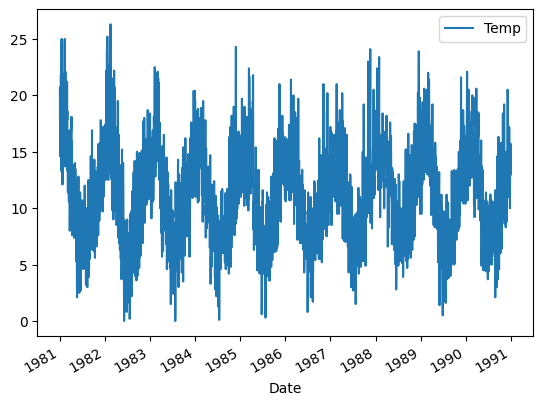

In [ ]:
df.plot()

Moving average

<Axes: xlabel='Date'>

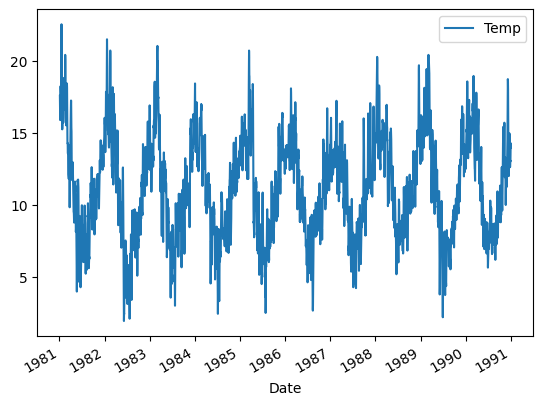

In [ ]:
window_size = 5
df_ma = df.rolling(window_size).mean()

df_ma.plot()

In [ ]:
df_ma.head(10)

,Temp
Date,
1981-01-01,NaN
1981-01-02,NaN
1981-01-03,NaN
1981-01-04,NaN
1981-01-05,17.56
1981-01-06,16.58
1981-01-07,16.16
1981-01-08,15.88
1981-01-09,17.32


## A.1. Time Series Decomposition

### A.1.0. Persiapan data

Membaca data dari https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv

In [ ]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


Melihat tipe data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


Mengubah tipe data

In [ ]:
df['Date'] = pd.to_datetime(df['Date'],format="%Y-%m-%d")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   datetime64[ns]
 1   Temp    3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


Menjadikan date sebagai index

In [ ]:
df = df.set_index('Date')
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


Plot data

<Axes: xlabel='Date'>

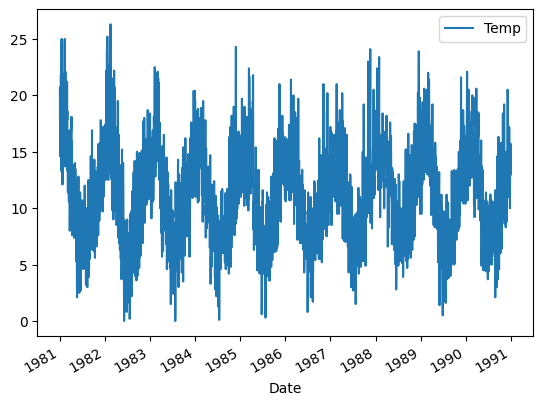

In [ ]:
df.plot()

### A.1.1. Decomposition

Install statsmodels versi terbaru

In [ ]:
#!pip install statsmodels==0.13.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 60.0 MB/s eta 0:00:00
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.13.5
    Uninstalling statsmodels-0.13.5:
      Successfully uninstalled statsmodels-0.13.5


Menggunakan Classical Decomposition

<Axes: xlabel='Date'>

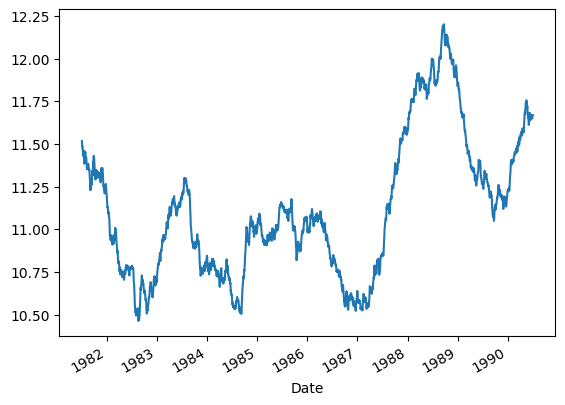

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_cd = seasonal_decompose(x=df,model='additive',period=365)

df_cd.trend.plot()

<Axes: xlabel='Date'>

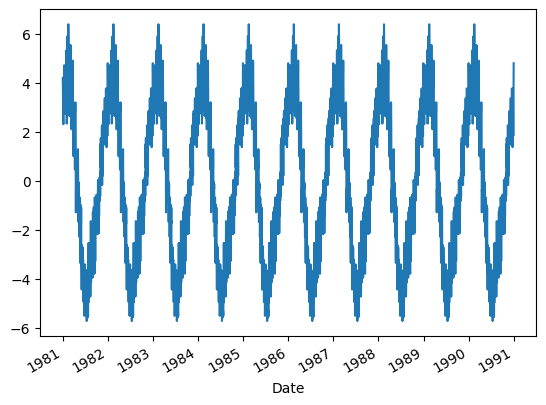

In [ ]:
df_cd.seasonal.plot()

<Axes: xlabel='Date'>

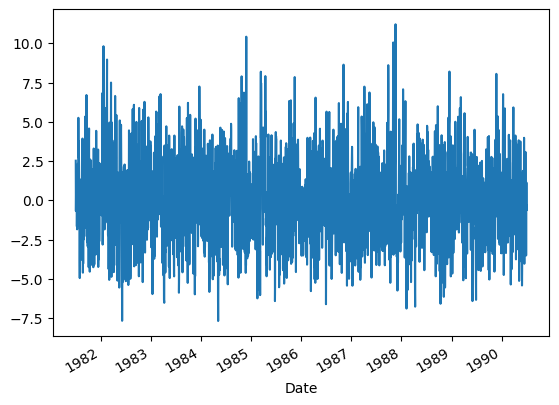

In [ ]:
df_cd.resid.plot()

Menggunakan STL

<Axes: xlabel='Date'>

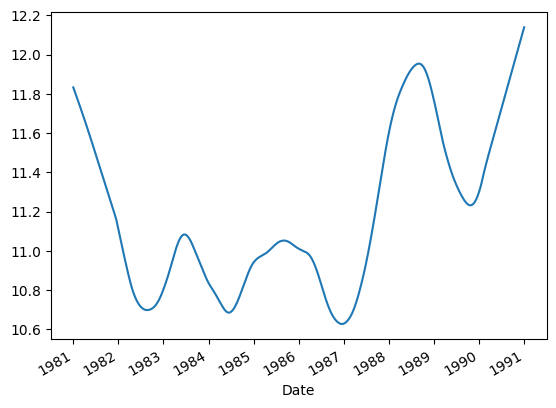

In [ ]:
from statsmodels.tsa.seasonal import STL

df_stl = STL(df,period=365).fit()

df_stl.trend.plot()

<Axes: xlabel='Date'>

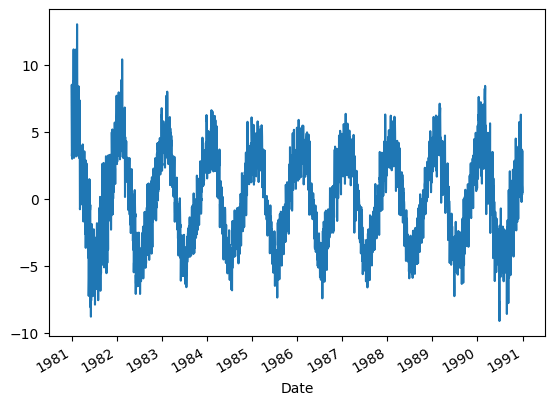

In [ ]:
df_stl.seasonal.plot()

<Axes: xlabel='Date'>

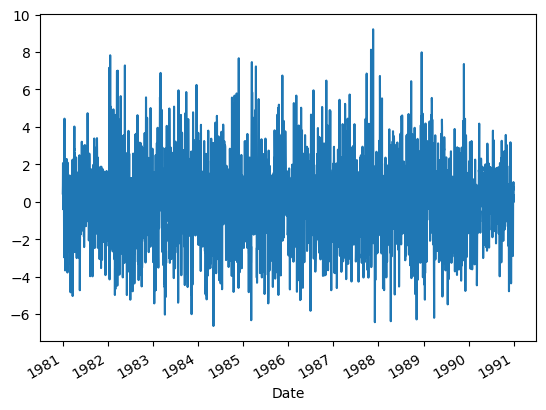

In [ ]:
df_stl.resid.plot()

## A.2. Time Series Stationarity

### A.2.0. Persiapan data

Pengambilan data

https://fred.stlouisfed.org/series/CBBTCUSD

In [ ]:
import pandas as pd

df_tss = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=718&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=CBBTCUSD&scale=left&cosd=2022-07-09&coed=2023-07-09&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Daily%2C%207-Day&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2023-07-09&revision_date=2023-07-09&nd=2014-12-01")
df_tss.head()

,DATE,CBBTCUSD
0,2022-07-09,21573.37
1,2022-07-10,20806.95
2,2022-07-11,19942.91
3,2022-07-12,19302.71
4,2022-07-13,20206.62


In [ ]:
df_tss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DATE      366 non-null    object 
 1   CBBTCUSD  366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


Mengubah tipe data

In [ ]:
df_tss['DATE'] = pd.to_datetime(df_tss['DATE'],format='%Y-%m-%d')
df_tss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DATE      366 non-null    datetime64[ns]
 1   CBBTCUSD  366 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB


Mengubah date menjadi index

In [ ]:
df_tss = df_tss.set_index('DATE')
df_tss.head()

,CBBTCUSD
DATE,
2022-07-09,21573.37
2022-07-10,20806.95
2022-07-11,19942.91
2022-07-12,19302.71
2022-07-13,20206.62


Plot data

<Axes: xlabel='DATE'>

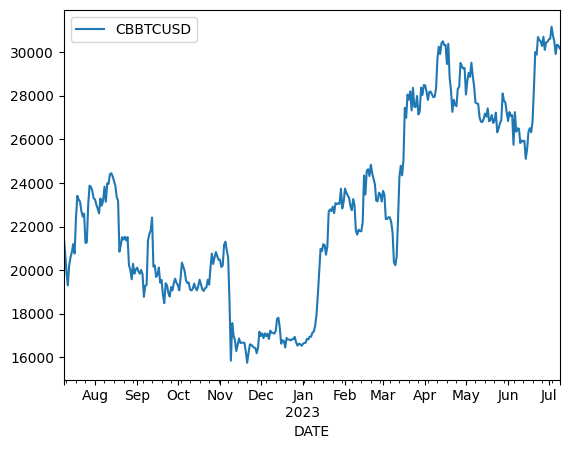

In [ ]:
df_tss.plot()

### A.2.1. Cek Stationary
Menggunakan ADF Test

H0: Ada unit root

H1: Tidak ada unit root

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(df_tss)
adf_test

(-0.8313970726658995,
 0.8097250257459074,
 0,
 365,
 {'1%': -3.4483935212959844,
  '5%': -2.8694912343676497,
  '10%': -2.571005879151811},
 5451.3898420397045)

Karena p-value lebih dari alpha (0.05) -> H0 diterima -> ada unit root -> non stationary

### A.2.2. Membuat data menjadi stationary

Log Transformation

<Axes: xlabel='DATE'>

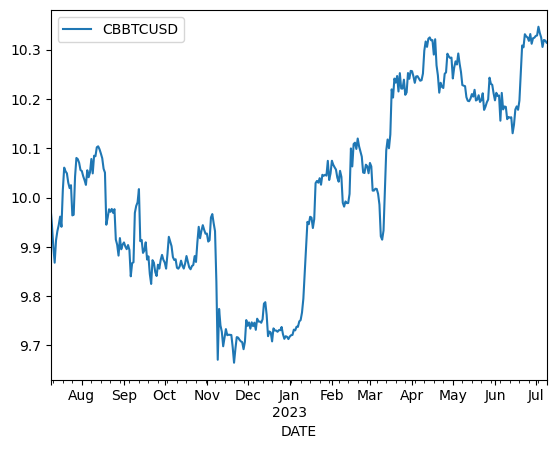

In [ ]:
import numpy as np

np.log(df_tss).plot()

Menguji hasil log transform dengan ADF

Box Cox Transformation

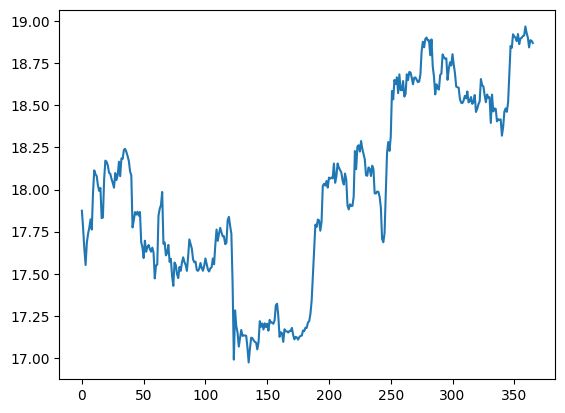

In [ ]:
from scipy.stats import boxcox
from matplotlib import pyplot as plt

df_box,fitted_lambda = boxcox(df_tss['CBBTCUSD'])
plt.plot(df_box)

Menguji hasil box cox transform dengan ADF

First-Order Differencing

<Axes: xlabel='DATE'>

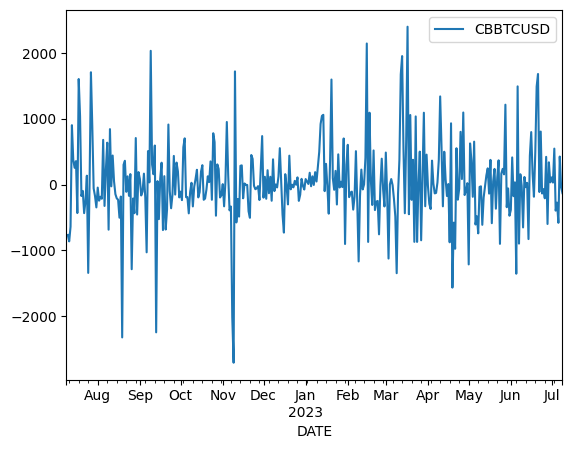

In [ ]:
df_diff = df_tss.diff()
df_diff.plot()

In [ ]:
df_diff.head()

,CBBTCUSD
DATE,
2022-07-09,NaN
2022-07-10,-766.42
2022-07-11,-864.04
2022-07-12,-640.20
2022-07-13,903.91


Menguji hasil first-order differencing dengan ADF

In [ ]:
adfuller(df_diff[1:])

(-12.847603707270208,
 5.438123344908024e-24,
 1,
 363,
 {'1%': -3.448493650810824,
  '5%': -2.8695352280356556,
  '10%': -2.5710293341377715},
 5429.387636862366)

# B. Forecasting

## B.1. Forecastability

Install library antropy

In [ ]:
!pip install antropy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.8 MB/s eta 0:00:00
  Created wheel for antropy: filename=antropy-0.1.5-py3-none-any.whl size=16900 sha256=12a67d5fa4924252518813db1d4a2446bcbbb15bc1f8feab0928f5a79b23db64
  Stored in directory: /root/.cache/pip/wheels/fb/11/46/bd2dbc64d2a915050ce7e0e57b0d34f4e0ac34010acae88053
Successfully built antropy


Menghitung sample entropy

In [ ]:
import antropy

antropy.sample_entropy(df_tss['CBBTCUSD'])

0.28566390829554383

In [ ]:
antropy.sample_entropy(df_diff[1:]['CBBTCUSD'])

1.5946146928975515

## B.2. Exponential Smoothing

Melihat info data

In [ ]:
df_tss.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2022-07-09 to 2023-07-09
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CBBTCUSD  366 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


Menyiapkan train dan test

In [ ]:
train = df_tss[:300]
test = df_tss[300:]

In [ ]:
train

,CBBTCUSD
DATE,
2022-07-09,21573.37
2022-07-10,20806.95
2022-07-11,19942.91
2022-07-12,19302.71
2022-07-13,20206.62
...,...
2023-04-30,29271.16
2023-05-01,28056.44
2023-05-02,28682.78


In [ ]:
test

,CBBTCUSD
DATE,
2023-05-05,29514.95
2023-05-06,28907.66
2023-05-07,28425.00
2023-05-08,27682.70
2023-05-09,27647.15
...,...
2023-07-05,30492.71
2023-07-06,29910.89
2023-07-07,30337.33


### B.2.1. Single Exponential Smoothing

[28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97115547 28806.97115547 28806.97115547
 28806.97115547 28806.97

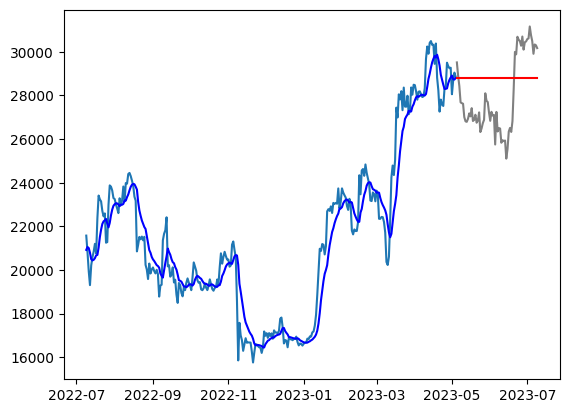

In [ ]:
from matplotlib import pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import numpy as np

model = SimpleExpSmoothing(np.asarray(train))

fit1 = model.fit(smoothing_level=.2)
pred1 = fit1.forecast(66)
print(pred1)
print(fit1)

plt.figure()
plt.plot(train.index, train.values)
plt.plot(test.index, test.values, color="gray", label="truth")
plt.plot(train.index,fit1.fittedvalues,color="blue")
plt.plot(test.index,pred1,color="red")
plt.show()

### B.2.2. Holt's Linear Trend


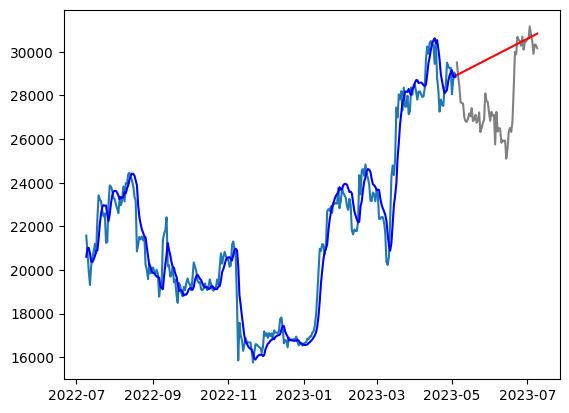

In [ ]:
from statsmodels.tsa.holtwinters import Holt

model = Holt(np.asarray(train))

fit1 = model.fit(smoothing_level=.3, smoothing_trend=.05)
pred1 = fit1.forecast(66)

plt.figure()
plt.plot(train.index, train.values)
plt.plot(test.index, test.values, color="gray", label="truth")
plt.plot(train.index,fit1.fittedvalues[:300],color="blue")
plt.plot(test.index,pred1,color="red")
plt.show()

### B.2.3. Holt's Winter

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:915: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


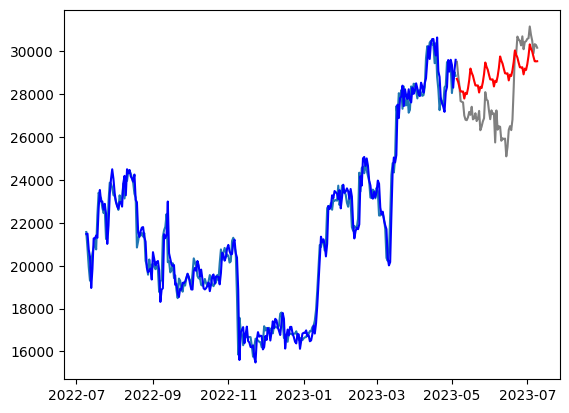

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(np.asarray(train), trend="add", seasonal="add", seasonal_periods=12)

fit1 = model.fit()
pred1 = fit1.forecast(66)

plt.figure()
plt.plot(train.index, train.values)
plt.plot(test.index, test.values, color="gray", label="truth")
plt.plot(train.index,fit1.fittedvalues[:300],color="blue")
plt.plot(test.index,pred1,color="red")
plt.show()